# 340StringMC GCD Hulls from `I3TruthExtractorPONE`

Build geometry hulls through `I3TruthExtractorPONE.set_gcd(...)` and plot the extractor-owned hulls for 102-string, 160-string, and full geometry.

In [4]:
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

GRAPHNET_SRC = Path("/project/def-nahee/kbas/graphnet/src")
if str(GRAPHNET_SRC) not in sys.path:
    sys.path.insert(0, str(GRAPHNET_SRC))

PATHS_PY = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/paths.py")
spec = importlib.util.spec_from_file_location("paths", PATHS_PY)
paths = importlib.util.module_from_spec(spec)
spec.loader.exec_module(paths)

from graphnet.data.extractors.icecube.i3truthextractor import I3TruthExtractorPONE


## GCD Paths

In [5]:
GCD_PATHS = {
    "102_string": Path(paths.GCD_TRIMMED["340StringMC"]["102_string"]),
    "160_string": Path(paths.GCD_TRIMMED["340StringMC"]["160_string"]),
    "full_geometry": Path(paths.GCD["340StringMC"]),
}

for label, gcd_path in GCD_PATHS.items():
    print(f"{label:14s} {gcd_path}")


102_string     /project/def-nahee/kbas/Graphnet-Applications/Metadata/GCD/340StringMC/102_string.i3.gz
160_string     /project/def-nahee/kbas/Graphnet-Applications/Metadata/GCD/340StringMC/160_string.i3.gz
full_geometry  /project/6008051/pone_simulation/GCD_Library/PONE_800mGrid.i3.gz


## Build Extractors

In [6]:
def build_truth_extractor_for_gcd(label, gcd_path):
    extractor = I3TruthExtractorPONE(name=f"truth_{label}")
    extractor.set_gcd(str(gcd_path))
    return extractor

extractors = {
    label: build_truth_extractor_for_gcd(label, gcd_path)
    for label, gcd_path in GCD_PATHS.items()
}

def extractor_positions(extractor):
    return np.array(
        [
            [omgeo.position.x, omgeo.position.y, omgeo.position.z]
            for omgeo in extractor._gcd_dict.values()
        ],
        dtype=float,
    )

geometry_positions = {
    label: extractor_positions(extractor)
    for label, extractor in extractors.items()
}

for label, positions in geometry_positions.items():
    print(f"[{label}]")
    print("  DOMs:", positions.shape[0])
    print("  hull vertices:", len(extractors[label].hull.vertices))
    print("  x:", positions[:, 0].min(), positions[:, 0].max())
    print("  y:", positions[:, 1].min(), positions[:, 1].max())
    print("  z:", positions[:, 2].min(), positions[:, 2].max())
    print()


graphnet [MainProcess] INFO     2026-07-07 11:29:08 - I3TruthExtractorPONE.__init__ - Writing log to logs/graphnet_20260707-112908.log
[102_string]
  DOMs: 32640
  hull vertices: 18
  x: -720.0 600.0
  y: -522.8718707889798 308.5125168440811
  z: -450.0 500.0

[160_string]
  DOMs: 51200
  hull vertices: 18
  x: -720.0 600.0
  y: -522.8718707889798 308.5125168440811
  z: -450.0 500.0

[full_geometry]
  DOMs: 108800
  hull vertices: 36
  x: -760.0 760.0
  y: -730.717967697245 724.2047106606115
  z: -450.0 500.0



## Plot Helpers

In [7]:
def set_equal_3d_limits(ax, positions):
    center = positions.mean(axis=0)
    span = (positions.max(axis=0) - positions.min(axis=0)).max() / 2
    ax.set_xlim(center[0] - span, center[0] + span)
    ax.set_ylim(center[1] - span, center[1] + span)
    ax.set_zlim(center[2] - span, center[2] + span)

def plot_extractor_hull_3d(label, extractor, positions, dom_alpha=0.08, hull_alpha=0.10):
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection="3d")

    # Single source of truth: use the hull built by I3TruthExtractorPONE.set_gcd.
    faces = [positions[simplex] for simplex in extractor.hull.simplices]
    poly = Poly3DCollection(
        faces,
        alpha=hull_alpha,
        linewidths=0.25,
        edgecolors="gray",
    )
    poly.set_facecolor("tab:blue")
    ax.add_collection3d(poly)

    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        s=1,
        alpha=dom_alpha,
        color="gray",
        label="GCD DOMs",
    )

    set_equal_3d_limits(ax, positions)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"{label}: I3TruthExtractorPONE GCD hull")
    ax.legend(loc="upper left")
    plt.show()

def plot_extractor_hull_topdown(label, positions, dom_alpha=0.12):
    xy = positions[:, :2]
    xy_hull = ConvexHull(xy)
    vertices = np.r_[xy_hull.vertices, xy_hull.vertices[0]]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(
        xy[vertices, 0],
        xy[vertices, 1],
        color="tab:blue",
        linewidth=2,
        label="XY convex hull",
    )
    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        s=2,
        alpha=dom_alpha,
        color="gray",
        label="GCD DOMs",
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(f"{label}: top-down GCD hull")
    ax.legend(loc="best")
    plt.show()


## Individual Geometry Plots

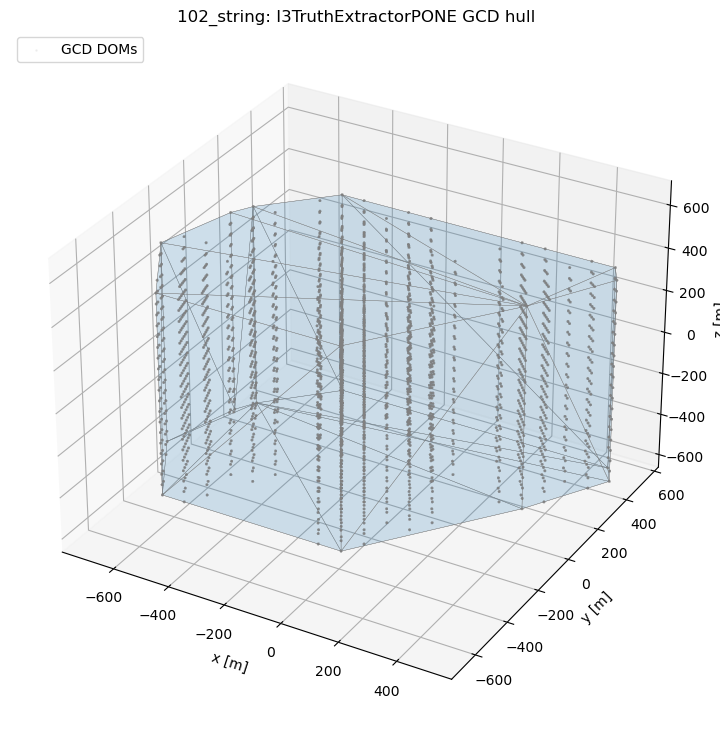

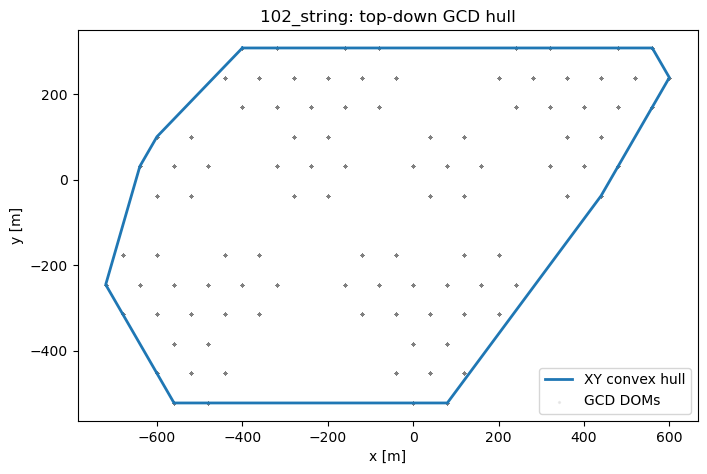

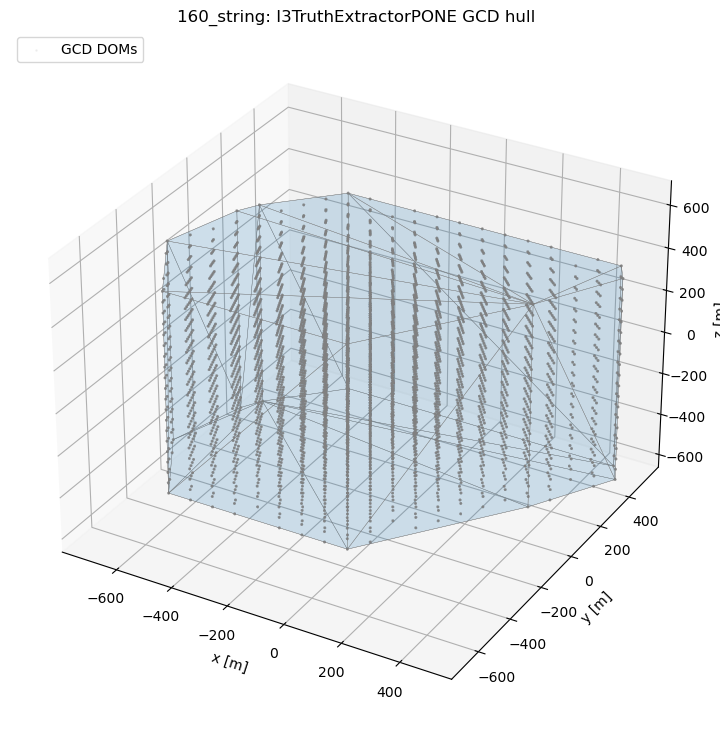

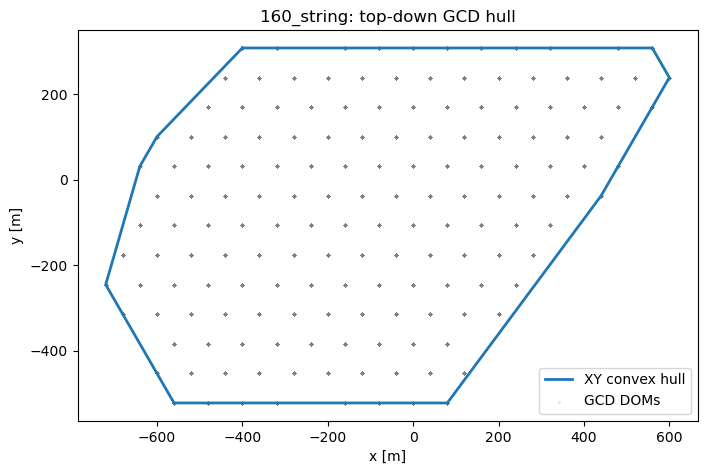

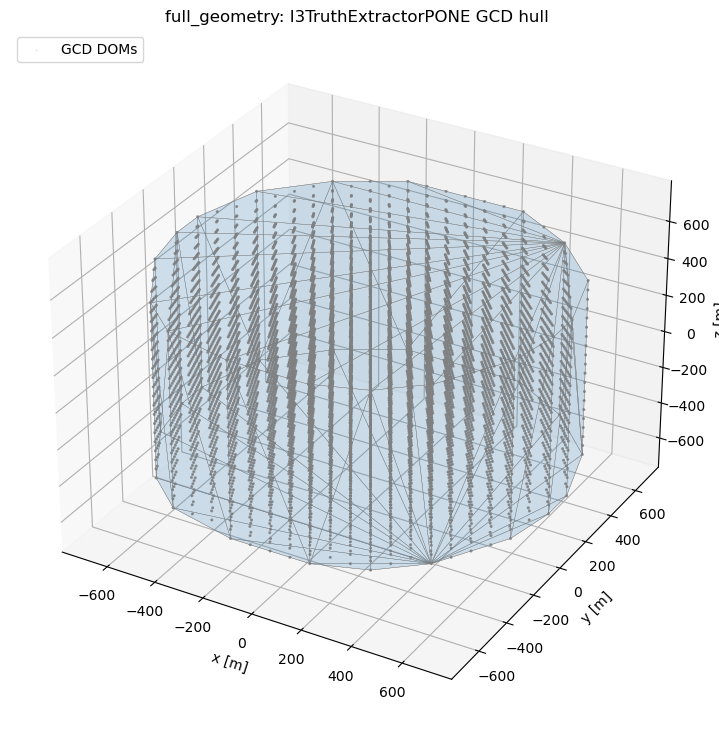

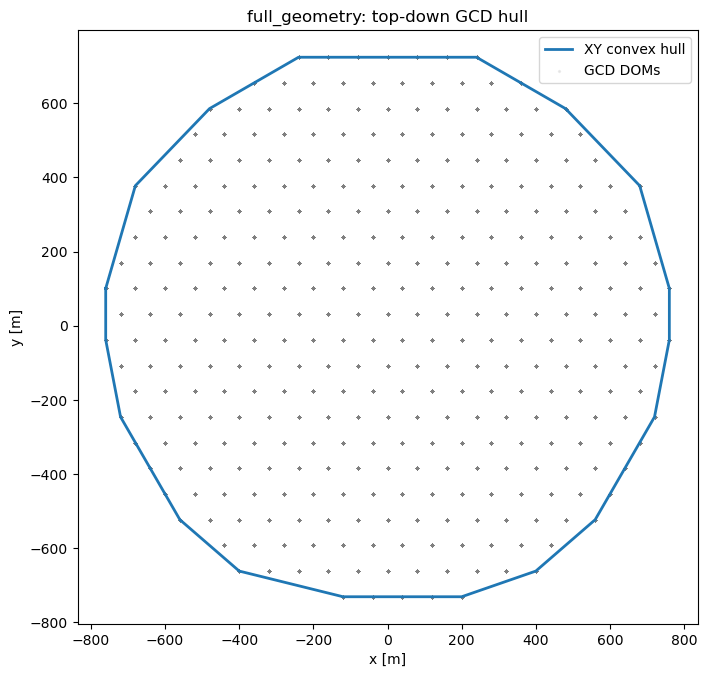

In [8]:
for label in ["102_string", "160_string", "full_geometry"]:
    plot_extractor_hull_3d(label, extractors[label], geometry_positions[label])
    plot_extractor_hull_topdown(label, geometry_positions[label])


## Overlay: Top-Down Comparison

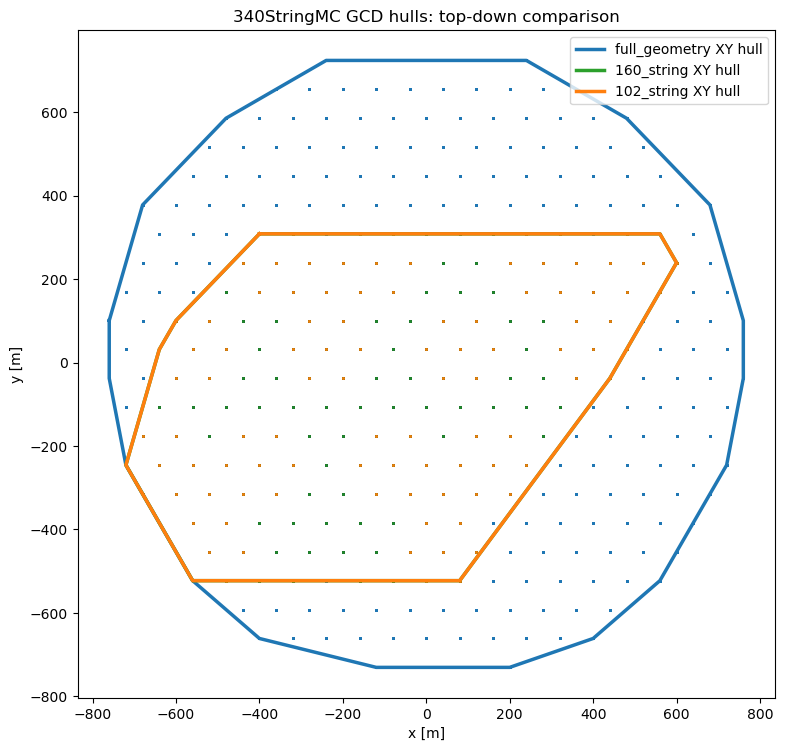

In [9]:
colors = {
    "102_string": "tab:orange",
    "160_string": "tab:green",
    "full_geometry": "tab:blue",
}

fig, ax = plt.subplots(figsize=(9, 9))
for label in ["full_geometry", "160_string", "102_string"]:
    positions = geometry_positions[label]
    xy = positions[:, :2]
    xy_hull = ConvexHull(xy)
    vertices = np.r_[xy_hull.vertices, xy_hull.vertices[0]]
    ax.plot(
        xy[vertices, 0],
        xy[vertices, 1],
        color=colors[label],
        linewidth=2.5,
        label=f"{label} XY hull",
    )
    ax.scatter(
        positions[:, 0],
        positions[:, 1],
        s=1,
        alpha=0.04,
        color=colors[label],
    )

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("340StringMC GCD hulls: top-down comparison")
ax.legend(loc="best")
plt.show()


## Optional: Check Points Against Each Extractor Hull

In [10]:
def inside_extractor_hull(label, point):
    return extractors[label]._inside_detector(np.asarray(point, dtype=float))


In [11]:

# Example:
point = [0.0, 0.0, 0.0]
{label: inside_extractor_hull(label, point) for label in extractors}


{'102_string': True, '160_string': True, 'full_geometry': True}

In [12]:

# Example:
point = [400.0, -400.0, 0.0]
{label: inside_extractor_hull(label, point) for label in extractors}


{'102_string': False, '160_string': False, 'full_geometry': True}